# MAE 223 — Tutorial: Spectral Analysis

This tutorial has two parts:

- **Part 1** — How does chunk size (number of segments) affect spectral resolution and stability? You will experiment with the La Jolla tide gauge data.
- **Part 2** — Apply the full spectral analysis pipeline to a new dataset: significant wave height from the SAFARI research buoy in the central Pacific.

Work through the exercises in order. Cells marked `# YOUR CODE HERE` require you to write code. Reflection questions should be answered in the provided markdown cells.

The `spectrumCB` function is defined in the cell directly below — run it first before proceeding.

In [2]:
import numpy as np
from scipy.signal import detrend as scipy_detrend


def spectrumCB(time, data, chunk):
    """
    Compute a one-sided Power Spectral Density (PSD) using Welch's method:
    50% overlapping segments, linear detrending, FFT, and ensemble averaging.

    Parameters
    ----------
    time  : array-like
        Time vector in decimal days. Used only to compute mean sample interval.
    data  : array-like
        Data values. Must be NaN-free before calling.
    chunk : int
        Number of samples per segment. Larger chunk -> finer frequency
        resolution but fewer segments and a noisier estimate.

    Returns
    -------
    f        : ndarray  — one-sided frequency vector [cpd]
    a        : ndarray  — averaged PSD [units² / cpd]
    parseval : float    — ratio ∫PSD df / var(data); should be ≈ 1.0
    """
    data  = np.asarray(data,  dtype=float)
    time  = np.asarray(time,  dtype=float)
    chunk = int(chunk)

    # --- split into 50% overlapping segments ---
    segments = []
    step = chunk // 2
    ind  = 0
    while ind + chunk <= len(data):
        segments.append(data[ind : ind + chunk])
        ind += step

    # --- frequency vector ---
    dt = np.nanmean(np.diff(time))       # mean sample interval [days]
    fn = 1.0 / (2.0 * dt)               # Nyquist frequency [cpd]
    N  = chunk
    T  = dt * N                          # segment length [days]
    df = 1.0 / T                         # frequency resolution [cpd]
    f  = np.arange(0, fn + df / 2, df)  # one-sided frequency vector
    nf = len(f)

    # --- compute and average PSD across segments ---
    A = np.empty((len(segments), nf))
    for i, seg in enumerate(segments):
        seg_dt   = scipy_detrend(seg)            # remove linear trend
        fft_vals = np.fft.fft(seg_dt)            # full FFT
        amp = np.abs(fft_vals[:nf]) ** 2         # one-sided amplitude²
        amp = amp / N ** 2                       # normalize DFT output
        amp = amp * 2                            # fold negative frequencies
        amp = amp / df                           # convert to density [units²/cpd]
        A[i] = amp
    a = A.mean(axis=0)

    # --- Parseval check ---
    variance = np.nanstd(data) ** 2
    int_spec  = np.trapezoid(a, f)
    parseval  = int_spec / variance

    print(f"  Segments used:  {len(segments)}")
    print(f"  Parseval check: {parseval:.4f}  (ideal = 1.00)")
    return f, a, parseval


---
# Part 1 — Understanding Spectral Resolution

## Purpose

When you call `spectrumCB(time, data, chunk)`, the `chunk` argument controls how many samples go into each segment of Welch's method. This single parameter determines a fundamental tradeoff in spectral estimation — and understanding it is essential for interpreting any spectrum you compute.

In this part, you will:
1. Load the familiar La Jolla tide gauge record
2. Compute spectra using four different chunk sizes
3. Plot them side by side and observe how the spectra change
4. Answer reflection questions that build physical intuition about the tradeoff

## Background: The Resolution–Stability Tradeoff

Welch's method divides your time series into overlapping **segments**, computes a periodogram for each, and averages them together. The length of each segment — the chunk size — controls two competing properties of the resulting spectrum.

### Frequency resolution

The **frequency resolution** `df` is the smallest frequency difference the spectrum can distinguish:

$$\Delta f = \frac{1}{T_{\text{segment}}} = \frac{1}{\text{chunk} \times dt}$$

where `dt` is the sample interval in days. A **longer segment** gives **finer frequency resolution** — the spectral peaks are sharper and you can distinguish constituents that are close together in frequency (like M₂ and S₂, which are only ~0.07 cpd apart).

### Spectral stability

**Spectral stability** (or smoothness) comes from averaging many independent segment estimates. More segments means more averaging, which reduces the noise-like fluctuations in the spectrum. But — here is the tradeoff — **more segments means shorter segments**, which means **coarser frequency resolution**.

### Intuition

Think of it like a photograph:
- **Long segments (few chunks):** High-resolution image, but grainy because you only have a few exposures to average. Peaks are sharp, but the background is noisy.
- **Short segments (many chunks):** Smooth image from many exposures, but the fine detail is blurred. Peaks are broad and may merge together.

There is no universally "correct" choice — it depends on what you are trying to resolve. For tidal analysis, you need fine enough resolution to separate individual tidal constituents. For a broad overview of energy distribution, more smoothing is fine.

| Setting | Chunk size | Segment length | df | Stability |
|---------|-----------|---------------|-----|----------|
| Very few chunks | Large | Long | Fine | Low (noisy) |
| Many chunks | Small | Short | Coarse | High (smooth) |

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# =============================================================================
# Load the La Jolla NOAA tide gauge record
# =============================================================================
# la_jolla_tide.json contains the full ~100-year NOAA record (1925–2025),
# sampled hourly. Sea level is in millimetres relative to a fixed datum.
# Missing observations are stored as JSON null (Python reads these as None).

with open('la_jolla_tide.json') as f:
    lj = json.load(f)

# Replace None (JSON null) with np.nan so NumPy can handle missing values.
sea_level_raw = np.array(
    [np.nan if v is None else v for v in lj['sea_level']]
)  # [mm]

# -------------------------------------------------------------------------
# Convert ISO timestamp strings to decimal days since the record start
# -------------------------------------------------------------------------
# spectrumCB uses the time vector only to compute dt (mean sample interval).
# We express time in days: parse each string -> timedelta -> total seconds / 86400.
t_parsed = [datetime.strptime(s, '%Y-%m-%dT%H:%M') for s in lj['time']]
t0       = t_parsed[0]                         # reference epoch (record start)
time_lj  = np.array(
    [(t - t0).total_seconds() / 86400.0 for t in t_parsed]
)  # [decimal days since 1925-01-01]

dt_lj = np.nanmean(np.diff(time_lj))           # mean sample interval [days] ≈ 1/24

# -------------------------------------------------------------------------
# Linearly interpolate across missing values (NaNs)
# -------------------------------------------------------------------------
# spectrumCB requires a NaN-free input. np.interp evaluates a piecewise
# linear interpolant at all time points, using only the valid (non-NaN) data.
nan_mask         = np.isnan(sea_level_raw)
sea_level_interp = np.interp(
    time_lj,               # evaluate at all times (including gaps)
    time_lj[~nan_mask],    # times with valid observations
    sea_level_raw[~nan_mask]  # corresponding valid sea-level values
)

print(f"Record:  {lj['metadata']['start']}  ->  {lj['metadata']['end']}")
print(f"Samples: {len(sea_level_interp):,}  |  Missing filled: {nan_mask.sum():,}")
print(f"dt:      {dt_lj * 24:.4f} hours")

Record:  1925-01-01T00:00  ->  2025-02-28T22:59
Samples: 878,016  |  Missing filled: 48,512
dt:      1.0000 hours


## Exercise 1 — Compare Four Chunk Sizes

Below is a loop that computes the PSD of the La Jolla tide gauge record using different chunk sizes. The structure is given — your job is to fill in the list of chunk counts to try and the corresponding labels.

**Instructions:**
1. Choose four values for `num_chunks_list` — the number of segments to divide the record into. Try a wide range (e.g., from very few segments to many). Suggested values: `[2, 5, 10, 40]`.
2. Fill in a matching `labels` list with descriptive strings for the legend (e.g., `'2 chunks'`).
3. Run the cell. The Parseval output will confirm the normalization is correct for each run.

The plotting cell after this one will overlay all four spectra automatically.

In [4]:
# =============================================================================
# Exercise 1: Choose chunk sizes to compare
# =============================================================================

# YOUR CODE HERE — fill in the list of number-of-chunks values to try.
# These integers control how many equal segments the record is divided into.
# Try a wide range so the tradeoff is clearly visible in the plot.
num_chunks_list = [50, 100, 500, 1000]   # YOUR CODE HERE: e.g. [2, 5, 10, 40]

# YOUR CODE HERE — fill in a label for each entry above.
# These strings will appear in the plot legend.
labels = ['20 chunks', '50 chunks', '100 chunks', '1000 chunks']   # YOUR CODE HERE

# -------------------------------------------------------------------------
# Loop: compute PSD for each chunk setting
# -------------------------------------------------------------------------
# We store the results in a list of tuples so the plotting cell can access them.
results = []   # will hold (f, psd, label) for each run

for n_chunks, label in zip(num_chunks_list, labels):
    chunk_size = len(sea_level_interp) // n_chunks   # samples per segment
    seg_len_days = chunk_size * dt_lj                 # segment length [days]
    df = 1.0 / seg_len_days                           # frequency resolution [cpd]

    print(f"--- {label}: chunk = {chunk_size:,} samples  |  "
          f"T_seg = {seg_len_days:.1f} days  |  df = {df:.4f} cpd")

    f_out, psd_out, _ = spectrumCB(time_lj, sea_level_interp, chunk_size)
    results.append((f_out, psd_out, label))
    print()

--- 20 chunks: chunk = 17,560 samples  |  T_seg = 731.7 days  |  df = 0.0014 cpd
  Segments used:  99
  Parseval check: 0.9774  (ideal = 1.00)

--- 50 chunks: chunk = 8,780 samples  |  T_seg = 365.8 days  |  df = 0.0027 cpd
  Segments used:  199
  Parseval check: 0.9710  (ideal = 1.00)

--- 100 chunks: chunk = 1,756 samples  |  T_seg = 73.2 days  |  df = 0.0137 cpd
  Segments used:  999
  Parseval check: 0.9551  (ideal = 1.00)

--- 1000 chunks: chunk = 878 samples  |  T_seg = 36.6 days  |  df = 0.0273 cpd
  Segments used:  1999
  Parseval check: 0.9513  (ideal = 1.00)



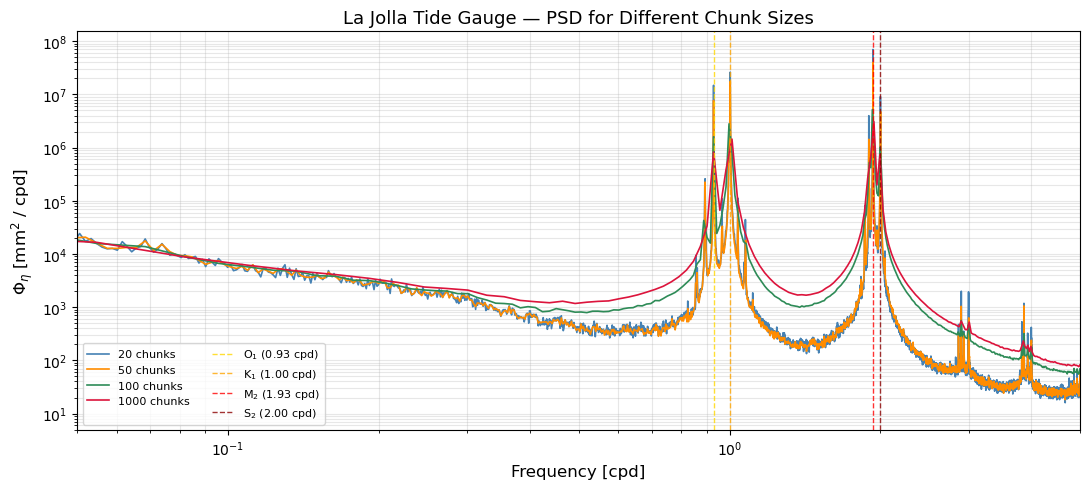

In [5]:
# =============================================================================
# Plot all four PSDs overlaid on a single log-log axes
# =============================================================================
# Using a colormap so each chunk setting gets a distinct, visually clear color.
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, ax = plt.subplots(figsize=(11, 5))

for (f_r, psd_r, lbl), color in zip(results, colors):
    # Skip index 0 (zero-frequency DC bin) to avoid log(0) on the x-axis
    ax.loglog(f_r[1:], psd_r[1:], lw=1.2, color=color, label=lbl)

# -------------------------------------------------------------------------
# Tidal constituent reference lines
# -------------------------------------------------------------------------
# Vertical dashed lines mark known tidal frequencies so you can judge
# how well each chunk setting resolves the individual peaks.
#
#   O₁  — principal lunar diurnal        period = 25.82 h  (~0.93 cpd)
#   K₁  — lunisolar diurnal              period = 23.93 h  (1.00 cpd)
#   M₂  — principal lunar semidiurnal    period = 12.42 h  (~1.93 cpd)
#   S₂  — principal solar semidiurnal    period = 12.00 h  (2.00 cpd)
tidal_lines = [
    (24 / 25.82,  'O$_1$ (0.93 cpd)',  'gold'),
    (1.0,         'K$_1$ (1.00 cpd)',  'orange'),
    (24 / 12.42,  'M$_2$ (1.93 cpd)', 'red'),
    (24 / 12.00,  'S$_2$ (2.00 cpd)', 'darkred'),
]
for freq, lbl, clr in tidal_lines:
    ax.axvline(freq, color=clr, ls='--', lw=1.0, alpha=0.8, label=lbl)

# Axis formatting
ax.set_xlabel('Frequency [cpd]', fontsize=12)
ax.set_ylabel(r'$\Phi_\eta$ [mm$^2$ / cpd]', fontsize=12)
ax.set_title('La Jolla Tide Gauge — PSD for Different Chunk Sizes', fontsize=13)
ax.set_xlim([0.05, 5])                      # focus on tidal frequency band
ax.legend(fontsize=8, loc='lower left', ncol=2)
ax.grid(True, which='both', alpha=0.3)      # grid on both major and minor log ticks
plt.tight_layout()
plt.show()

## Reflection Questions — Part 1

Answer all three questions in the markdown cell below. Show any calculations inline.

---

**Q1.** Which chunk setting gives the sharpest tidal peaks (e.g., at M₂ and S₂)? Why does a larger chunk size produce sharper peaks? Refer to the formula for `df` in your answer.

---

**Q2.** Which chunk setting gives the smoothest spectral curve (least jagged background)? What is the tradeoff you accept when you choose many short segments? Is this tradeoff acceptable for tidal analysis?

---

**Q3.** M₂ (1.932 cpd) and S₂ (2.000 cpd) are separated by approximately **0.068 cpd**. To resolve them as distinct peaks, the frequency resolution must satisfy `df < 0.068 cpd`.

  a. Using `df = 1 / T_segment`, calculate the **minimum segment length** (in days) needed to resolve M₂ from S₂.

  b. The La Jolla record is sampled hourly (dt = 1/24 day). How many samples must each segment contain?

  c. With 878,016 total hourly samples, what is the **maximum number of non-overlapping segments** you could use while still meeting this resolution requirement? (Hint: `n_chunks = N_total / chunk_size`)

**Your answers:**

Q1: The 2-chunks setting produced the sharpest tidal peaks. This is because frequency resolution and chunk size are inversely proportional. Because of this, a large number of chunks leads to a small frequency resolution, and therefore sharper peaks.

Q2: The 40-chunks setting gives the smoothest spectral curve. The tradeoff is that frequency resolution is coarser. This means broader peaks and fine detail is lost. For tidal analysis, this may not be acceptable because some tidal frequencies are close apart, and this detail could be lost with an extremely high number of chunks.

Q3a: Using algebra, $T_{segment} = 1 / df$. Based on a maximum $df$ of 0.068 cpd, the minimum $T_{segment}$ to resolve M₂ from S₂ is 14.71 days.

Q3b: Since $\Delta f = \frac{1}{T_{\text{segment}}} = \frac{1}{\text{chunk} \times dt}$, $T_\text{segment} = \text{chunk} \times dt$ and $\text{chunk} = T_\text{segment}/dt$. Therefore, $\text{chunk} = 14.71 \ \text{days} / \frac{1}{24} \ \text{day} = 353 \ \text{samples}$.


Q3c: Based on the equation given, $n_\text{chunks} = N_\text{total} / \text{chunk} = 878016 \ \text{samples} / 353 \ \text{samples} = 2487 \ \text {segments}$.

---
# Part 2 — SAFARI Wave Analysis

## Introduction

**SAFARI** (Sub-Arctic Front and Ring Investigation) is a 2025–2026 WHOI field campaign studying ocean dynamics at the sub-Arctic front in the central North Pacific. As part of the experiment, a Surface Wave Instrument Float with Tracking (SWIFT) buoy was deployed at approximately **33°25'N, 158°W** — roughly 1,500 km northwest of Hawaii in the open Pacific.

The buoy measures **significant wave height (Hs)**, defined as the average height of the tallest one-third of waves. It is computed from the variance of vertical acceleration measured by an onboard IMU: $H_s = 4\sqrt{\text{var}(\eta)}$, where $\eta$ is the sea surface displacement. Hs is a **bulk parameter** — it summarizes the sea state in a single number rather than resolving individual wave frequencies.

Data are transmitted via **Iridium satellite telemetry**, which means transmissions occur when the satellite is overhead. As a result, the sampling is **irregular** — the time between observations varies. Before computing a spectrum, you will need to interpolate the data onto a regular time grid.

Because Hs is a bulk parameter sampled every ~2 hours, its spectrum will **not** show individual wave frequencies (swell, wind waves) — those require raw surface elevation sampled at ~10 Hz. Instead, the Hs spectrum reveals variability at **weather and synoptic timescales**: storm passages (~4-day periods), synoptic weather patterns (~10-day periods), and possible diurnal or tidal modulation of wind fields.

In this part you will:
1. Load and inspect the SAFARI dataset
2. Parse the irregular timestamps into decimal days
3. Interpolate onto a regular 2-hour grid
4. Plot a quick look at the first 30 days
5. Compute and interpret the power spectral density

## Exercise 2 — Load the SAFARI Data

Load `safari_waves.json` and print the metadata so you know what you are working with before touching the data.

In [6]:
# =============================================================================
# Exercise 2: Load safari_waves.json and inspect the metadata
# =============================================================================

with open('safari_waves.json') as f:
    safari = json.load(f)

# The JSON has three top-level keys: 'metadata', 'time', and 'hs'.
# 'metadata' is a dict with information about the dataset.
# 'time'     is a list of ISO timestamp strings.
# 'hs'       is a list of significant wave height values in metres.

# YOUR CODE HERE — print each key and value in safari['metadata'].
# Hint: loop over safari['metadata'].items() and print key: value.
print("--- SAFARI Metadata ---")
for key, value in safari['metadata'].items():   # YOUR CODE HERE
    print(f"  {key}: {value}")

--- SAFARI Metadata ---
  source: WHOI Upper Ocean Processes Group — SAFARI 2025 buoy
  location: 33 25 N, 158 W (central mid-latitude Pacific)
  variable: Significant wave height (Hs) from FFT of vertical acceleration
  units: m
  start: 2025-11-21T03:00
  end: 2026-04-01T03:00
  n_samples: 1246
  n_nulls: 0
  dt_nominal_hours: 2.53
  note: Sampling irregular (Iridium telemetry). Interpolate to regular grid before spectral analysis.


## Exercise 3 — Parse Timestamps into Decimal Days

Convert the ISO timestamp strings in `safari['time']` to decimal days since the start of the record. Use the same approach as the demo notebook:

1. Parse each string with `datetime.strptime` using format `'%Y-%m-%dT%H:%M'`
2. Subtract the first timestamp to get a `timedelta`
3. Convert to days via `.total_seconds() / 86400`

Store the result in a NumPy array called `time_safari`.

In [7]:
# =============================================================================
# Exercise 3: Parse ISO timestamps -> decimal days
# =============================================================================

# The timestamp format is '%Y-%m-%dT%H:%M'  (e.g., '2025-11-21T03:00')
# Step 1: parse each string into a Python datetime object
t_parsed_safari = [datetime.strptime(s, '%Y-%m-%dT%H:%M') for s in safari['time']]

t0_safari = t_parsed_safari[0]    # reference epoch: first observation

# Step 2 & 3: compute decimal days since t0_safari for every timestamp.
# YOUR CODE HERE — build a list comprehension that subtracts t0_safari,
# calls .total_seconds(), and divides by 86400. Wrap in np.array().
time_safari = np.array(
    [(t - t0_safari).total_seconds() / 86400.0 for t in t_parsed_safari]   # YOUR CODE HERE
)  # [decimal days since record start]

# Extract raw Hs values as a NumPy float array
hs_safari = np.array(safari['hs'], dtype=float)   # [m]

# Compute the actual (irregular) mean sample interval for reference
dt_safari_actual = np.nanmean(np.diff(time_safari))   # [days]

print(f"Record start:  {t0_safari}")
print(f"Total duration: {time_safari[-1]:.1f} days")
print(f"N samples (raw): {len(time_safari):,}")
print(f"Mean dt (raw):   {dt_safari_actual * 24:.2f} hours  (nominal: "
      f"{safari['metadata']['dt_nominal_hours']} h)")

Record start:  2025-11-21 03:00:00
Total duration: 131.0 days
N samples (raw): 1,246
Mean dt (raw):   2.53 hours  (nominal: 2.53 h)


## Exercise 4 — Interpolate onto a Regular Time Grid

`spectrumCB` assumes **evenly-spaced** data. The SAFARI data are irregularly sampled (Iridium telemetry does not transmit at fixed intervals), so we must first interpolate Hs onto a uniform grid.

We will use a **2-hour grid** (`dt = 2/24` days), which is close to the nominal sampling interval and well above the Nyquist limit for any physically meaningful weather-band signal in Hs.

The interpolation is the same `np.interp` approach used for the NaN gaps in the La Jolla data — here, instead of filling a few missing points, we are re-sampling an entire irregular record onto a regular grid.

In [8]:
# =============================================================================
# Exercise 4: Interpolate SAFARI Hs onto a regular 2-hour grid
# =============================================================================

# Step 4a: build the regular time grid (pre-written)
# -------------------------------------------------------------------------
# np.arange(start, stop, step) generates evenly spaced values.
# We start at the first observation and stop at the last, with 2-hour steps.
dt_regular = 2.0 / 24.0                          # 2 hours in decimal days
time_regular = np.arange(
    time_safari[0],                               # start: first SAFARI observation
    time_safari[-1] + dt_regular,                 # stop: slightly past the last point
    dt_regular                                    # step: 2 hours
)  # [decimal days on a uniform grid]

# Step 4b: interpolate Hs onto the regular grid
# -------------------------------------------------------------------------
# YOUR CODE HERE — use np.interp to evaluate the Hs time series at every
# point in time_regular. The function signature is:
#   np.interp(x_new, x_known, y_known)
# where x_new = time_regular, x_known = time_safari, y_known = hs_safari.
hs_interp = np.interp(time_regular, time_safari, hs_safari)   # YOUR CODE HERE

# Step 4c: report the result
print(f"Regular grid:  dt = {dt_regular * 24:.1f} hours")
print(f"N samples (interpolated): {len(hs_interp):,}")
print(f"Hs range: {hs_interp.min():.2f} – {hs_interp.max():.2f} m")

Regular grid:  dt = 2.0 hours
N samples (interpolated): 1,574
Hs range: 1.27 – 9.62 m


## Exercise 5 — Quick Look Plot

Before computing any spectrum, always plot the raw (well, interpolated) signal. This sanity check helps you:
- Confirm the data look physically reasonable
- Spot any obvious artifacts introduced by interpolation
- Get an intuitive feel for the dominant variability before you see the spectrum

Plot the **first 30 days** of the interpolated Hs record. Axes labels and the title are given as comments. After making the plot, answer the questions below in a comment or in the reflection cell at the end of Part 2.

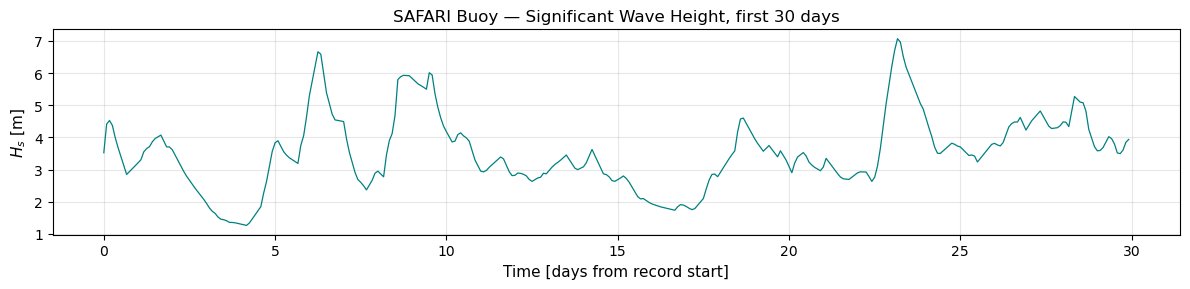

In [9]:
# =============================================================================
# Exercise 5: Quick look — first 30 days of interpolated Hs
# =============================================================================

# Number of 2-hour samples in 30 days
nplot = int(30.0 / dt_regular)   # = 30 days / (2/24 days per sample) = 360 samples

fig, ax = plt.subplots(figsize=(12, 3))

# YOUR CODE HERE — plot the first 'nplot' values of time_regular (x-axis)
# against the first 'nplot' values of hs_interp (y-axis).
# Use lw=0.9 and color='teal' to match the demo style.
ax.plot(time_regular[:nplot], hs_interp[:nplot], lw=0.9, color='teal')  # YOUR CODE HERE

# Axis labels (given — do not change)
ax.set_xlabel('Time [days from record start]', fontsize=11)
ax.set_ylabel('$H_s$ [m]', fontsize=11)
ax.set_title('SAFARI Buoy — Significant Wave Height, first 30 days', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Observation prompt (answer in the reflection cell at the end of Part 2):
# - What is the typical range of Hs over this period?
# - Can you identify any storm events (rapid rise in Hs)?
# - How long do the elevated Hs events last? What timescale does that suggest?

## Exercise 6 — Choose a Chunk Size and Compute the Spectrum

Now compute the PSD of the interpolated Hs record.

**You must decide how many segments to use.** Consider:
- The record is ~130 days long
- You want to resolve variability at periods of ~4–10 days (storm timescales)
- Aim for **at least 8 segments** to get a reasonably stable spectral estimate
- More segments = smoother spectrum, but coarser frequency resolution

In your code comment, state the frequency resolution `df` you achieve and confirm it is fine enough to distinguish the periods of interest.

In [18]:
# =============================================================================
# Exercise 6: Choose num_chunks and compute the SAFARI Hs spectrum
# =============================================================================

# YOUR CODE HERE — choose the number of segments.
# Aim for at least 8 for a stable estimate. Think about the frequency
# resolution you need to distinguish 4-day vs 10-day variability.
num_chunks_safari = 10   # YOUR CODE HERE: integer >= 8 recommended

# Compute samples per segment and the resulting frequency resolution
chunk_safari    = len(hs_interp) // num_chunks_safari   # samples per segment
seg_len_days    = chunk_safari * dt_regular              # segment length [days]
df_safari       = 1.0 / seg_len_days                    # frequency resolution [cpd]

# YOUR CODE HERE — in this comment, state your df:
# df = ____________ cpd  (= 1 / ______ days)
# This means you can distinguish variability separated by at least ____ days.

print(f"num_chunks:    {num_chunks_safari}")
print(f"chunk size:    {chunk_safari} samples = {seg_len_days:.1f} days per segment")
print(f"df:            {df_safari:.4f} cpd  (resolves periods separated by > {1/df_safari:.1f} days)")

# YOUR CODE HERE — call spectrumCB with the correct arguments.
# Store the outputs as f_safari, psd_safari, parseval_safari.
f_safari, psd_safari, parseval_safari = spectrumCB(   # YOUR CODE HERE
    time_regular, hs_interp, chunk_safari
)

num_chunks:    10
chunk size:    157 samples = 13.1 days per segment
df:            0.0764 cpd  (resolves periods separated by > 13.1 days)
  Segments used:  19
  Parseval check: 0.5103  (ideal = 1.00)


## Exercise 7 — Plot the SAFARI Hs Spectrum

Plot the PSD on a log-log scale. Reference lines are provided at key synoptic and tidal periods. The `ax.loglog(...)` call is yours to write.

**Why these reference lines?**
Since Hs is a bulk parameter sampled every 2 hours, the Nyquist frequency is 12 cpd (period = 2 hours). The physically meaningful variability in Hs is driven by weather-band and synoptic-scale forcing:

| Period | Frequency | Physical process |
|--------|-----------|------------------|
| 10 days | 0.1 cpd | Synoptic weather systems |
| 4 days | 0.25 cpd | Typical mid-latitude storm passage |
| 1 day | 1.0 cpd | Diurnal variability (wind, sea breeze) |
| 12 hours | 2.0 cpd | Semidiurnal (tidal modulation of winds?) |

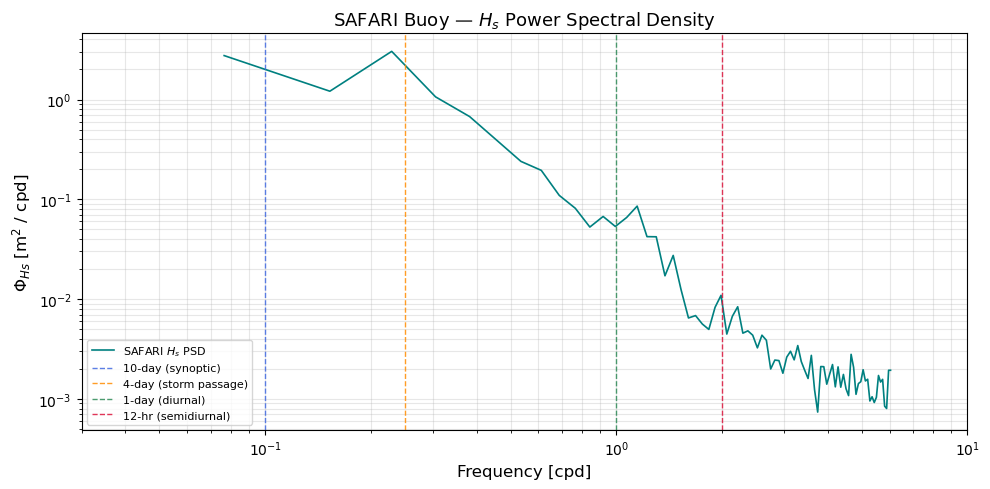

In [19]:
# =============================================================================
# Exercise 7: Plot the SAFARI Hs power spectral density
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# YOUR CODE HERE — plot f_safari[1:] vs psd_safari[1:] on a log-log scale.
# Skip index 0 (zero-frequency DC bin) to avoid log(0) on the x-axis.
# Use: lw=1.2, color='teal', label='SAFARI Hs PSD'
ax.loglog(f_safari[1:], psd_safari[1:], lw=1.2, color='teal', label='SAFARI $H_s$ PSD')  # YOUR CODE HERE

# -------------------------------------------------------------------------
# Reference lines at synoptic and tidal frequencies (pre-written)
# -------------------------------------------------------------------------
# These mark physically meaningful periods for a bulk wave height record.
# Frequencies are in cpd (cycles per day).
ref_lines_safari = [
    (1.0 / 10.0,  '10-day (synoptic)',       'royalblue'),
    (1.0 /  4.0,  '4-day (storm passage)',   'darkorange'),
    (1.0 /  1.0,  '1-day (diurnal)',         'seagreen'),
    (1.0 /  0.5,  '12-hr (semidiurnal)',     'crimson'),
]
for freq, lbl, clr in ref_lines_safari:
    ax.axvline(freq, color=clr, ls='--', lw=1.0, alpha=0.85, label=lbl)

# Axis labels and formatting
ax.set_xlabel('Frequency [cpd]', fontsize=12)
ax.set_ylabel(r'$\Phi_{Hs}$ [m$^2$ / cpd]', fontsize=12)
ax.set_title('SAFARI Buoy — $H_s$ Power Spectral Density', fontsize=13)
ax.set_xlim([0.03, 10])               # focus on weather to sub-daily range
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Reflection Questions — Part 2

Answer all three questions in the markdown cell below.

---

**Q4.** Look at your SAFARI Hs spectrum. What period (or frequency range) dominates the variability — where is most of the spectral energy? What physical process does this correspond to? Are the peaks consistent with what you observed in the quick look plot (Exercise 5)?

---

**Q5.** Is there detectable energy at the diurnal frequency (1 cpd) or semidiurnal frequency (2 cpd) in the Hs spectrum? Propose a physical mechanism that could cause Hs to vary at these frequencies in the open ocean. (Hint: think about what drives wind and how the ocean surface responds.)

---

**Q6.** Compare your SAFARI Hs spectrum to the La Jolla tide gauge spectrum from the demo notebook. Identify **two specific differences** (e.g., peak locations, slope of the background spectrum, sharpness of peaks) and explain what each difference tells you about the physical processes driving each signal. Why does one signal have extremely sharp, narrow peaks while the other has broad energy at many frequencies?

**Your answers:**

Q4: The frequency range between 10<sup>-0.8</sup> and 10<sup>-1.2</sup> cpd dominates variability, containing most of the spectral energy. This frequency range is equivalent to a period range of 6 to 15 days, corresponding to the lunar phase cycle. This period range is consistent with the peaks in the quick look plot in Exercise 5.

Q5: There is detectable energy and the diurnal and semidiurnal frequency. Variation at the diurnal frequency is due to the day/night cycle, while variation at the semidiurnal cycle is due to the tidal cycle.

Q6: The La Jolla tide gauge spectrum has peaks at diurnal and semidiurnal frequencies, while the SAFARI Hs spectrum has peaks at many frequencies; this means that the tidal cycle has little to no effect on SAFARI Hs spectrum. In addition, the slope of the background spectrum is much steeper for the La Jolla tide gauge spectrum than for the SAFARI Hs spectrum; this means that the tidal energy is concentrated at lower frequencies. The La Jolla tide gauge spectrium has sharp, narrow peaks because the chunk length is long enough to capture multiple tidal cycles. On the other hand, the SAFARI Hs spectrum had broad energy at many frequencies because each chunk only one "weather" cycle.